## 1. Data Loading & EDA

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('typhoon15_track.csv')
df.head()

,datetime_utc,lat,lon,pressure_hpa,max_wind_kt
0,2026-08-05 00:00,19.0,165.3,1000,30
1,2026-08-05 03:00,19.2,165.4,1000,30
2,2026-08-05 06:00,19.6,165.7,998,35
3,2026-08-05 09:00,21.2,166.3,996,35
4,2026-08-05 12:00,23.5,166.1,996,35


In [5]:
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])
df = df.sort_values('datetime_utc').reset_index(drop=True)
df.dtypes

datetime_utc    datetime64[ns]
lat                    float64
lon                    float64
pressure_hpa             int64
max_wind_kt              int64
dtype: object

In [6]:
df['dlat'] = df['lat'].diff()
df['dlon'] = df['lon'].diff()
df.tail(8)

,datetime_utc,lat,lon,pressure_hpa,max_wind_kt,dlat,dlon
42,2026-08-10 06:00:00,34.6,149.3,990,40,0.5,0.0
43,2026-08-10 09:00:00,35.1,148.4,990,40,0.5,-0.9
44,2026-08-10 12:00:00,35.2,147.4,990,40,0.1,-1.0
45,2026-08-10 15:00:00,36.2,146.8,985,45,1.0,-0.6
46,2026-08-10 18:00:00,36.7,145.7,985,45,0.5,-1.1
47,2026-08-10 21:00:00,37.1,145.0,985,45,0.4,-0.7
48,2026-08-11 00:00:00,36.9,143.8,985,45,-0.2,-1.2
49,2026-08-11 03:00:00,36.6,142.7,985,45,-0.3,-1.1


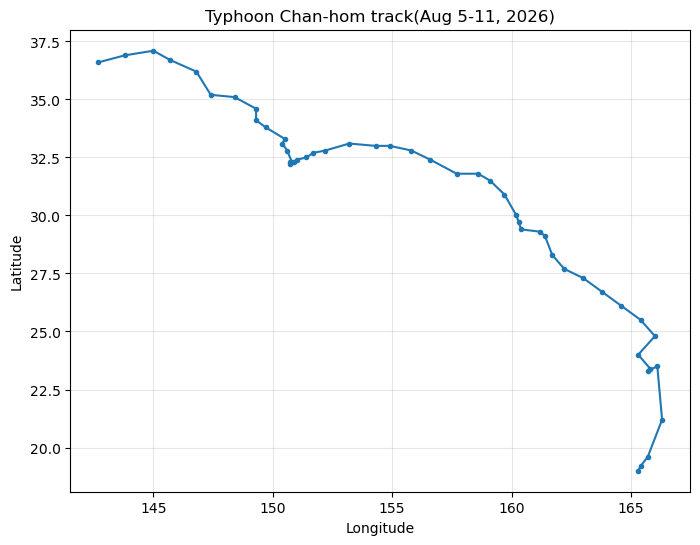

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df['lon'], df['lat'], marker='o', markersize=3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Typhoon Chan-hom track(Aug 5-11, 2026)')
plt.grid(alpha=0.3)
plt.show()

## 2. Forecasts (made before outcome known)

Forecasts made: 2026-08-11 ~21:30 JST, using track data through 2026-08-11 03:00 UTC.

In [8]:
last = df.iloc[-1]
v_lat = df['dlat'].iloc[-1]
v_lon = df['dlon'].iloc[-1]
print(last['lat'], last['lon'], v_lat, v_lon)

36.6 142.7 -0.29999999999999716 -1.1000000000000227


In [9]:
steps = 6
pred_lat_base = last['lat'] + v_lat * steps
pred_lon_base = last['lon'] + v_lon * steps
print(f'Baseline forecast: {pred_lat_base:.1f}N, {pred_lon_base:.1f}E')

Baseline forecast: 34.8N, 136.1E


In [10]:
import numpy as np

recent = df.tail(9).reset_index(drop=True)
t = np.arange(len(recent))
print(recent[['datetime_utc','lat','lon']])
print(t)

         datetime_utc   lat    lon
0 2026-08-10 03:00:00  34.1  149.3
1 2026-08-10 06:00:00  34.6  149.3
2 2026-08-10 09:00:00  35.1  148.4
3 2026-08-10 12:00:00  35.2  147.4
4 2026-08-10 15:00:00  36.2  146.8
5 2026-08-10 18:00:00  36.7  145.7
6 2026-08-10 21:00:00  37.1  145.0
7 2026-08-11 00:00:00  36.9  143.8
8 2026-08-11 03:00:00  36.6  142.7
[0 1 2 3 4 5 6 7 8]


In [11]:
A = np.vstack([np.ones_like(t), t]).T
print(A)

[[1 0]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]
 [1 6]
 [1 7]
 [1 8]]


In [12]:
b_lat, k_lat = np.linalg.lstsq(A, recent['lat'], rcond=None)[0]
print(f'intercept b = {b_lat:.3f}, slope k = {k_lat:+.3f} deg per 3h')

intercept b = 34.340, slope k = +0.373 deg per 3h


In [13]:
b_lon, k_lon = np.linalg.lstsq(A, recent['lon'], rcond=None)[0]
print(f'intercept b = {b_lon:.3f}, slope k = {k_lon:+.3f} deg per 3h')

intercept b = 149.916, slope k = -0.857 deg per 3h


In [14]:
t_future = 8 + steps
pred_lat_reg = b_lat + k_lat * t_future
pred_lon_reg = b_lon + k_lon * t_future
print(f'Regression forecast: {pred_lat_reg:.1f}N, {pred_lon_reg:.1f}E')

Regression forecast: 39.6N, 137.9E


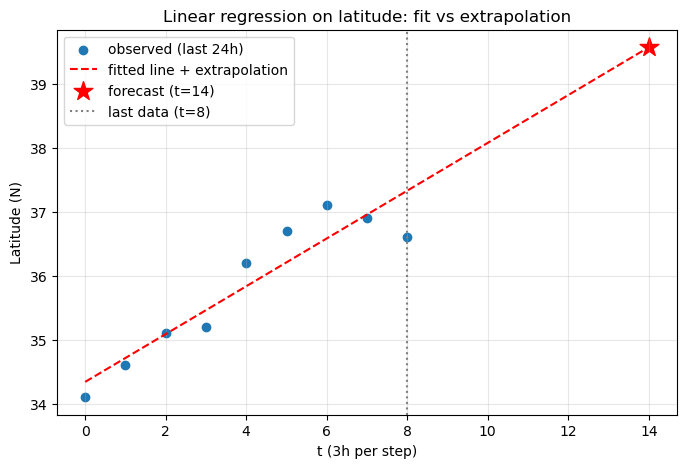

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(t, recent['lat'], label='observed (last 24h)')
t_line = np.arange(0, 15)
plt.plot(t_line, b_lat + k_lat * t_line, 'r--', label='fitted line + extrapolation')
plt.scatter([14], [pred_lat_reg], marker='*', s=200, color='red', label='forecast (t=14)')
plt.axvline(8, color='gray', ls=':', label='last data (t=8)')
plt.xlabel('t (3h per step)')
plt.ylabel('Latitude (N)')
plt.title('Linear regression on latitude: fit vs extrapolation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
for s in range(6, 12):
    jst = 6 + 3*(s-6)
    bl_lat = last['lat'] + v_lat*s
    bl_lon = last['lon'] + v_lon*s
    rg_lat = b_lat + k_lat*(8+s)
    rg_lon = b_lon + k_lon*(8+s)
    print(f'Aug12 {jst:02d}:00 JST | baseline {bl_lat:.1f}N {bl_lon:.1f}E | regression {rg_lat:.1f}N {rg_lon:.1f}E')

Aug12 06:00 JST | baseline 34.8N 136.1E | regression 39.6N 137.9E
Aug12 09:00 JST | baseline 34.5N 135.0E | regression 39.9N 137.1E
Aug12 12:00 JST | baseline 34.2N 133.9E | regression 40.3N 136.2E
Aug12 15:00 JST | baseline 33.9N 132.8E | regression 40.7N 135.4E
Aug12 18:00 JST | baseline 33.6N 131.7E | regression 41.1N 134.5E
Aug12 21:00 JST | baseline 33.3N 130.6E | regression 41.4N 133.6E


Extended to six horizons (Aug 12 06:00-21:00 JST): forecast made Aug 12 ~02:00 JST, data still through Aug 11 03:00 UTC.

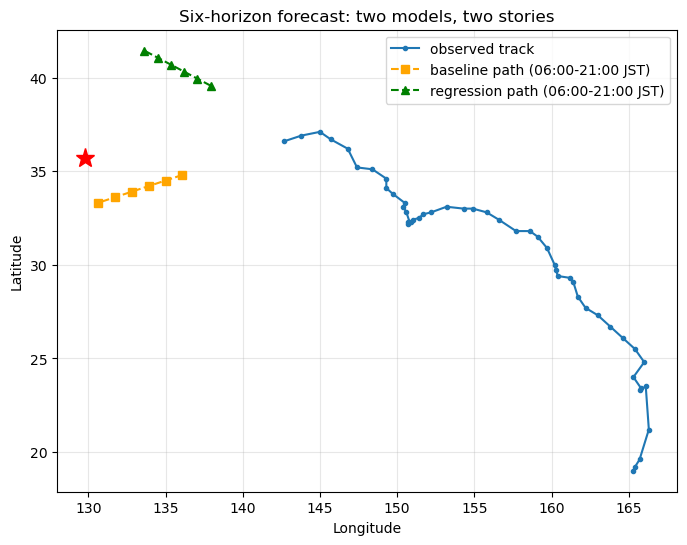

In [17]:
bl_lats, bl_lons, rg_lats, rg_lons = [], [], [], []
for s in range(6, 12):
    bl_lats.append(last['lat'] + v_lat*s)
    bl_lons.append(last['lon'] + v_lon*s)
    rg_lats.append(b_lat + k_lat*(8+s))
    rg_lons.append(b_lon + k_lon*(8+s))

plt.figure(figsize=(8, 6))
plt.plot(df['lon'],df['lat'], '-o', markersize=3, label='observed track')
plt.plot(bl_lons, bl_lats, '--s', color='orange', label='baseline path (06:00-21:00 JST)')
plt.plot(rg_lons, rg_lats, '--^', color='green', label='regression path (06:00-21:00 JST)')
plt.plot(129.8, 35.7, 'r*', markersize=14)
plt.xlabel('Longitude');plt.ylabel('Latitude')
plt.title('Six-horizon forecast: two models, two stories')
plt.legend(); plt.grid(alpha=0.3)
plt.show()